<a href="https://colab.research.google.com/github/WVF-1/Urban-Tree-Modeling/blob/main/Model_Building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 — Growing Better Cities
## Part 1 of 3: Building the Random Forest

**Building Data Together Data Science Newsletter**

This is the capstone of the urban forest series. Weeks 1–3 built and explored a 63-city predictor table (elevation, population density, impervious surface proxy, park land %, open water %) alongside each city's tree census profile. Week 3 stopped short of modeling on purpose.

This week we build that model: a **Random Forest regressor predicting tree density (`trees_per_km2`)** from the five land-use/geography predictors. The goal isn't a forecasting product — with only 63 cities, that would be overclaiming. The goal is a **planning aid**: a model honest enough about its own uncertainty to be a useful conversation-starter for urban planners asking "where would greening this city actually move the needle?"

**What this notebook does:**
1. Load the Week 3 predictor table, prep features/target
2. Compare cross-validation strategies (LOOCV vs. repeated K-fold) on n=63 — small-sample models need honest, not optimistic, evaluation
3. Small hyperparameter search
4. Final model: fit + honest out-of-fold predictions for every city
5. Export model + predictions for Notebooks 2 (interpretation/planning widget) and 3 (case studies/mapping)

**No linear regression baseline this time** — one model, fully showcased, per the newsletter's usual format.


## 0. Setup

In [1]:
!pip install -q scikit-learn joblib

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    LeaveOneOut, RepeatedKFold, GridSearchCV, cross_val_score, cross_val_predict
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid", font_scale=1.05)
NATURAL_PALETTE = ["#2E5339", "#6B8E4E", "#A9BA9D", "#C9A66B", "#8C6239", "#4A3728"]
sns.set_palette(NATURAL_PALETTE)

RANDOM_STATE = 42


## 1. Load data & prep features/target

In [3]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

CSV_NAME = "week3_city_predictors_clustered.csv"

if IN_COLAB:
    uploaded = files.upload()
    CSV_NAME = list(uploaded.keys())[0]

df = pd.read_csv(CSV_NAME)

TARGET = "trees_per_km2"
NUMERIC_FEATURES = [
    "elevation_m",
    "population_density_per_km2",
    "pct_impervious_proxy",
    "pct_parkland",
    "pct_water",
    "population",
]
CATEGORICAL_FEATURES = ["region"]

analysis_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]
df_model = df.dropna(subset=analysis_cols).copy()
print(f"Modeling on {len(df_model)} of {len(df)} cities (dropped rows with missing values)")

X = pd.get_dummies(df_model[NUMERIC_FEATURES + CATEGORICAL_FEATURES], columns=CATEGORICAL_FEATURES, drop_first=True)
y = df_model[TARGET].values
FEATURE_NAMES = X.columns.tolist()

print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")
X.head()


Saving week3_city_predictors.csv to week3_city_predictors.csv
Modeling on 12 of 63 cities (dropped rows with missing values)
Features (9): ['elevation_m', 'population_density_per_km2', 'pct_impervious_proxy', 'pct_parkland', 'pct_water', 'population', 'region_Northeast', 'region_South', 'region_West']


,elevation_m,population_density_per_km2,pct_impervious_proxy,pct_parkland,pct_water,population,region_Northeast,region_South,region_West
0,1587.0,1073.460579,0.428055,0.101283,0.008644,556495,False,False,True
1,61.0,2620.057374,0.433079,0.048618,0.028259,345012,False,False,True
2,190.0,1469.783272,0.537761,0.035914,0.044521,379577,False,True,False
3,336.0,1271.349084,0.694056,0.037766,0.007924,447841,False,True,False
4,1652.0,828.961278,0.303586,0.036362,0.013026,345803,False,False,True


## 2. Why CV strategy matters at n=63

A single train/test split on 63 rows means your test set is ~12-19 cities — small enough that the reported score is mostly noise from *which* cities happened to land in the test set. We compare **Leave-One-Out CV** (train on 62, predict 1, repeated for every city — deterministic, uses all data) against **repeated 5-fold CV** (faster, but the fold assignment itself adds variance) to see how much the evaluation number moves around depending on the CV scheme, before trusting either one.


LOOCV (aggregate):        R2 = -0.204   MAE = 281.5
Repeated 5-fold (100 runs): R2 mean = -647.388 +/- 3464.573
Repeated 5-fold (100 runs): MAE mean = 287.5 +/- 136.2


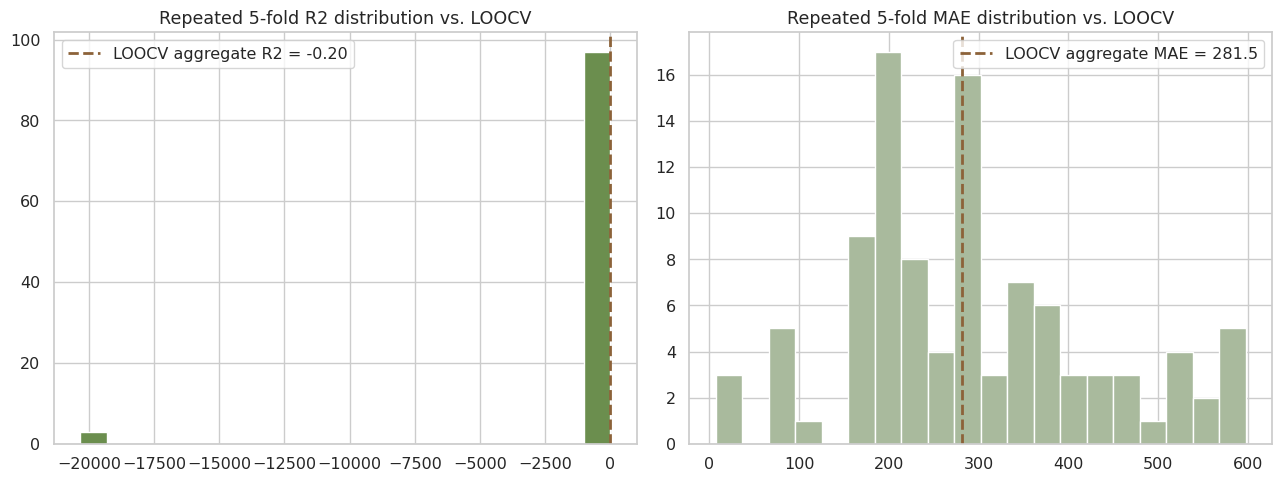

In [4]:
baseline_rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)

loo = LeaveOneOut()
# Note: per-fold R^2 is undefined with LOOCV (each test fold has 1 point), so
# we never score per-fold. Instead we collect every out-of-fold prediction and
# compute one aggregate R^2/MAE across all 63 predictions at once.
loo_preds = cross_val_predict(baseline_rf, X, y, cv=loo)
loo_r2 = r2_score(y, loo_preds)
loo_mae = mean_absolute_error(y, loo_preds)

rkf = RepeatedKFold(n_splits=5, n_repeats=20, random_state=RANDOM_STATE)
rkf_r2_scores = cross_val_score(baseline_rf, X, y, cv=rkf, scoring="r2")
rkf_mae_scores = -cross_val_score(baseline_rf, X, y, cv=rkf, scoring="neg_mean_absolute_error")

print(f"LOOCV (aggregate):        R2 = {loo_r2:.3f}   MAE = {loo_mae:.1f}")
print(f"Repeated 5-fold (100 runs): R2 mean = {rkf_r2_scores.mean():.3f} +/- {rkf_r2_scores.std():.3f}")
print(f"Repeated 5-fold (100 runs): MAE mean = {rkf_mae_scores.mean():.1f} +/- {rkf_mae_scores.std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(rkf_r2_scores, bins=20, color=NATURAL_PALETTE[1], edgecolor="white")
axes[0].axvline(loo_r2, color=NATURAL_PALETTE[4], linewidth=2, linestyle="--", label=f"LOOCV aggregate R2 = {loo_r2:.2f}")
axes[0].set_title("Repeated 5-fold R2 distribution vs. LOOCV")
axes[0].legend()

axes[1].hist(rkf_mae_scores, bins=20, color=NATURAL_PALETTE[2], edgecolor="white")
axes[1].axvline(loo_mae, color=NATURAL_PALETTE[4], linewidth=2, linestyle="--", label=f"LOOCV aggregate MAE = {loo_mae:.1f}")
axes[1].set_title("Repeated 5-fold MAE distribution vs. LOOCV")
axes[1].legend()

plt.tight_layout()
plt.savefig("week4_cv_strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


The repeated-fold spread shows how much a single 5-fold split could mislead you — the LOOCV aggregate is the more stable, defensible number for n=63, and it's what we report going forward. We'll use repeated 5-fold *only* for the hyperparameter search below (LOOCV grid search at every parameter combination is needlessly expensive), then re-validate the winner with LOOCV.


## 3. Small hyperparameter search

In [5]:
param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 4, 6, 8],
    "min_samples_leaf": [1, 2, 4],
}

search_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid, cv=search_cv, scoring="r2", n_jobs=-1,
)
grid.fit(X, y)

print("Best params:", grid.best_params_)
print(f"Best repeated-5-fold R2: {grid.best_score_:.3f}")

results = pd.DataFrame(grid.cv_results_).sort_values("mean_test_score", ascending=False)
results[["params", "mean_test_score", "std_test_score"]].head(10)


Best params: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 400}
Best repeated-5-fold R2: -598.181


,params,mean_test_score,std_test_score
25,"{'max_depth': 6, 'min_samples_leaf': 4, 'n_est...",-598.181409,1949.040143
34,"{'max_depth': 8, 'min_samples_leaf': 4, 'n_est...",-598.181409,1949.040143
16,"{'max_depth': 4, 'min_samples_leaf': 4, 'n_est...",-598.181409,1949.040143
7,"{'max_depth': None, 'min_samples_leaf': 4, 'n_...",-598.181409,1949.040143
26,"{'max_depth': 6, 'min_samples_leaf': 4, 'n_est...",-604.744906,1971.273131
35,"{'max_depth': 8, 'min_samples_leaf': 4, 'n_est...",-604.744906,1971.273131
17,"{'max_depth': 4, 'min_samples_leaf': 4, 'n_est...",-604.744906,1971.273131
8,"{'max_depth': None, 'min_samples_leaf': 4, 'n_...",-604.744906,1971.273131
6,"{'max_depth': None, 'min_samples_leaf': 4, 'n_...",-654.430465,2142.522205
15,"{'max_depth': 4, 'min_samples_leaf': 4, 'n_est...",-654.430465,2142.522205


## 4. Final model: LOOCV validation + OOB check

In [6]:
best_params = grid.best_params_

final_rf = RandomForestRegressor(random_state=RANDOM_STATE, oob_score=True, **best_params)

# Honest out-of-fold predictions for every city (used for residual analysis in Notebook 3)
loo_preds_final = cross_val_predict(final_rf, X, y, cv=LeaveOneOut())
final_loo_r2 = r2_score(y, loo_preds_final)
final_loo_mae = mean_absolute_error(y, loo_preds_final)
final_loo_rmse = np.sqrt(mean_squared_error(y, loo_preds_final))

# Fit on all 63 cities for interpretation (Notebook 2) - OOB score is a free,
# built-in cross-validation-like estimate on the *fitted* model
final_rf.fit(X, y)

print("=== Final Random Forest (LOOCV-evaluated) ===")
print(f"LOOCV R2:   {final_loo_r2:.3f}")
print(f"LOOCV MAE:  {final_loo_mae:.1f} trees/km2")
print(f"LOOCV RMSE: {final_loo_rmse:.1f} trees/km2")
print(f"OOB R2 (sanity check on full-data fit): {final_rf.oob_score_:.3f}")
print(f"Target range in data: {y.min():.0f} - {y.max():.0f} trees/km2 (mean {y.mean():.0f})")


=== Final Random Forest (LOOCV-evaluated) ===
LOOCV R2:   -0.126
LOOCV MAE:  300.1 trees/km2
LOOCV RMSE: 351.5 trees/km2
OOB R2 (sanity check on full-data fit): -0.110
Target range in data: 5 - 1096 trees/km2 (mean 304)


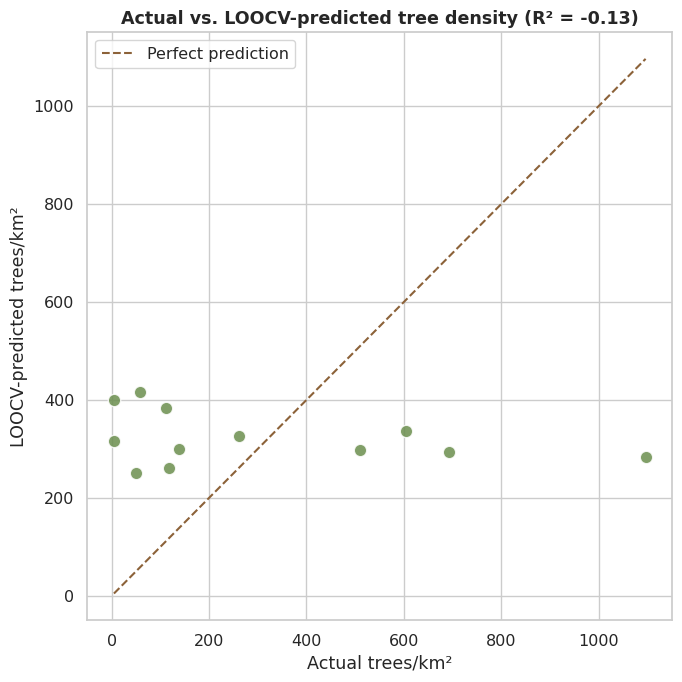

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y, loo_preds_final, color=NATURAL_PALETTE[1], edgecolor="white", s=80, alpha=0.85)
lims = [min(y.min(), loo_preds_final.min()), max(y.max(), loo_preds_final.max())]
ax.plot(lims, lims, color=NATURAL_PALETTE[4], linestyle="--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual trees/km²")
ax.set_ylabel("LOOCV-predicted trees/km²")
ax.set_title(f"Actual vs. LOOCV-predicted tree density (R² = {final_loo_r2:.2f})", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("week4_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


### Reading this honestly

If `R²` here is modest (which is likely at n=63 with noisy, proxy-heavy features), that's not a failure — it's the correct amount of humility for this dataset size. The value of this model isn't "precisely forecast tree density"; it's "rank which levers (park %, impervious %, density) matter most, on average, across the cities we do have data for" — which is exactly what Notebook 2 does next.


## 5. Export model, predictions, and metadata

In [8]:
joblib.dump(final_rf, "week4_rf_model.joblib")

predictions_df = df_model[["city", "state", "region", TARGET] + NUMERIC_FEATURES].copy()
predictions_df["predicted_trees_per_km2"] = loo_preds_final
predictions_df["residual"] = predictions_df[TARGET] - predictions_df["predicted_trees_per_km2"]
predictions_df.to_csv("week4_predictions.csv", index=False)

metadata = {
    "target": TARGET,
    "feature_names": FEATURE_NAMES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "best_params": best_params,
    "loo_r2": final_loo_r2,
    "loo_mae": final_loo_mae,
    "loo_rmse": final_loo_rmse,
    "oob_r2": final_rf.oob_score_,
    "n_cities": len(df_model),
}
with open("week4_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved: week4_rf_model.joblib, week4_predictions.csv, week4_model_metadata.json")

if IN_COLAB:
    files.download("week4_rf_model.joblib")
    files.download("week4_predictions.csv")
    files.download("week4_model_metadata.json")


Saved: week4_rf_model.joblib, week4_predictions.csv, week4_model_metadata.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes for the writeup

- One model, fully showcased — no baseline comparison this time, by design.
- LOOCV is the headline metric; repeated 5-fold was used only to keep the hyperparameter search computationally sane.
- `residual` in the exported predictions (actual − predicted) is the key column for Notebook 3's "who's over/under-performing relative to their land-use profile" case studies.
- This model is a planning conversation-starter, not a forecasting tool — say that explicitly in the newsletter text, not just in code comments.

Next: Notebook 2 opens the model up — feature importance, partial dependence, SHAP, and the interactive "what if we added more park land here?" widget.
